# VERY IMPORTANT
# DO NOT PRESS RUN ALL
# TWO SEGMENT HERE TAKES 20 MINUTES TO RUN
#GO DOWN UNTIL YOU SEE THE RUN HERE PART
from Bryan

What we are doing
We are going to compare housing resale prices, as such purchases are expensive we hope it can help users be prepared to pay for the amendities they require

We will be running 3 analysis, one on internal factor such as the house charetsitcis and prices
one on the nearby features like if there is a supermarket and so on
and the final analysis take both into account
then we determine the key factors affceting the resale prices

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Read the file
import pandas as pd

Mounted at /content/drive


In [ ]:
csv_file_path = '/content/drive/MyDrive/Web Analytic Final Project G20/ResalePrice2017.csv'

try:
    # pandas is already imported in a previous cell as 'pd'
    df_resale_price = pd.read_csv(csv_file_path)
    print("Successfully loaded the CSV file into a DataFrame. Here are the first 5 rows:")
    display(df_resale_price.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded the CSV file into a DataFrame. Here are the first 5 rows:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


### DO NOT RUN THE BELOW CODE
## IT TAKES 13 MINUTES
## DONT RUN IF YOU CANNOT WAIT 13 MINUTES

In [ ]:
import requests, time
import pandas as pd

df = df_resale_price.copy()

# get unique street names (this automatically removes duplicates)
unique_streets = df["street_name"].dropna().unique()

geocode_cache = {}

for street in unique_streets:

    # if cached, skip (automatically handles duplicates)
    if street in geocode_cache:
        continue

    url = "https://nominatim.openstreetmap.org/search"
    params = {
        "q": street + ", Singapore",
        "format": "json",
        "addressdetails": 1,
    }

    time.sleep(1)  # required by Nominatim

    try:
        resp = requests.get(
            url,
            params=params,
            headers={"User-Agent": "Mozilla/5.0"}
        )
        data = resp.json()

        if len(data) == 0:
            geocode_cache[street] = (None, None)
        else:
            lat = float(data[0]["lat"])
            lon = float(data[0]["lon"])
            geocode_cache[street] = (lat, lon)

    except:
        geocode_cache[street] = (None, None)


In [ ]:
df["lat"] = df["street_name"].map(lambda s: geocode_cache.get(s, (None, None))[0])
df["lon"] = df["street_name"].map(lambda s: geocode_cache.get(s, (None, None))[1])


In [ ]:
df.to_csv("df_resale_price_with_amenities.csv", index=False)
from google.colab import files
files.download("df_resale_price_with_amenities.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



```
# Sformatowano jako kod
```

End of the 13 minute segment

In [ ]:
csv_file_path = '/content/drive/MyDrive/Web Analytic Final Project G20/df_resale_price_with_amenities.csv'
import pandas as pd
try:

    df_resale_price_updated = pd.read_csv(csv_file_path)
    print("Successfully loaded the CSV file into a DataFrame. Here are the first 5 rows:")
    display(df_resale_price_updated.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded the CSV file into a DataFrame. Here are the first 5 rows:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,lat,lon
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,1.359432,103.855152
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,1.382661,103.838451
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,1.378698,103.835838
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,1.359432,103.855152
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,1.378698,103.835838


In [ ]:
gdf_flats = gdf_flats.to_crs(3857)  # already done before, but ensure
RADIUS = 500  # meters

for name, gdf_amenity in gdf_amenities.items():
    print(f"Processing {name}...")

    # Ensure amenity CRS matches flats
    gdf_amenity = gdf_amenity.to_crs(3857)

    # Vectorized distance matrix (fast enough for SG)
    dist_matrix = gdf_flats.geometry.apply(
        lambda pt: gdf_amenity.distance(pt) <= RADIUS
    )

    # Count True values per row
    gdf_flats[name] = dist_matrix.sum(axis=1)


Processing MRT...
Processing Bus Stop...
Processing Shopping Mall...
Processing Hawker centers/food courts...
Processing Primary and secondary school...
Processing Kindergarten/childcare center...
Processing Tuition center...
Processing Polyclinic and GP Clinics...
Processing Community Center...


In [ ]:
df_final = gdf_flats.drop(columns=["geometry"]).copy()
df_final.head()


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,lon,MRT,Bus Stop,Shopping Mall,Hawker centers/food courts,Primary and secondary school,Kindergarten/childcare center,Tuition center,Polyclinic and GP Clinics,Community Center
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,...,103.855152,0,12,0,2,2,0,0,0,1
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,...,103.838451,1,15,0,2,2,0,0,0,1
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,103.835838,0,16,0,1,1,2,0,0,0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,...,103.855152,0,12,0,2,2,0,0,0,1
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,103.835838,0,16,0,1,1,2,0,0,0


In [ ]:
df_final.to_csv("/content/amenities_joined.csv", index=False)
print("Saved to /content/amenities_joined.csv")
from google.colab import files
files.download("/content/amenities_joined.csv")



Saved to /content/amenities_joined.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# START HERE

In [ ]:
!ls "/content/drive/MyDrive"


ls: cannot access '/content/drive/MyDrive': No such file or directory


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Read the file
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Web Analytic Final Project G20/amenities_joined.csv'

try:
    # pandas is already imported in a previous cell as 'pd'
    df_resale_price = pd.read_csv(csv_file_path)
    print("Successfully loaded the CSV file into a DataFrame. Here are the first 5 rows:")
    display(df_resale_price.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Mounted at /content/drive
Successfully loaded the CSV file into a DataFrame. Here are the first 5 rows:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,...,lon,MRT,Bus Stop,Shopping Mall,Hawker centers/food courts,Primary and secondary school,Kindergarten/childcare center,Tuition center,Polyclinic and GP Clinics,Community Center
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,...,103.855152,0,12,0,2,2,0,0,0,1
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,...,103.838451,1,15,0,2,2,0,0,0,1
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,103.835838,0,16,0,1,1,2,0,0,0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,...,103.855152,0,12,0,2,2,0,0,0,1
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,...,103.835838,0,16,0,1,1,2,0,0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Linear Regression
R² - How much of price variation the model explains (0-1)

Accuracy - Percentage of price variations explained

Mean Absolute Error - Average error in SGD dollars

Error percentage - Error as % of average price

'MAE' - Mean Absolute Error in SGD

In [ ]:
df_resale_price.columns


Index(['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date',
       'remaining_lease', 'resale_price', 'lat', 'lon', 'MRT', 'Bus Stop',
       'Shopping Mall', 'Hawker centers/food courts',
       'Primary and secondary school', 'Kindergarten/childcare center',
       'Tuition center', 'Polyclinic and GP Clinics', 'Community Center'],
      dtype='object')

In [ ]:
# Ensure month is datetime
df_resale_price['month'] = pd.to_datetime(df_resale_price['month'], errors='coerce')

# Create year column
df_resale_price['year'] = df_resale_price['month'].dt.year


# Function to convert storey_range into midpoint
def storey_midpoint(storey_str):
    if pd.isna(storey_str):
        return np.nan

    storey_str = str(storey_str).strip()

    # If range format: "04 TO 06"
    if "TO" in storey_str:
        try:
            low, high = storey_str.split("TO")
            low = int(low.strip())
            high = int(high.strip())
            return (low + high) / 2
        except:
            return np.nan

    # If only a single number
    try:
        return float(storey_str)
    except:
        return np.nan


# Apply transformation
df_resale_price['storey_avg'] = df_resale_price['storey_range'].apply(storey_midpoint)

# Preview results
df_resale_price[['storey_range', 'storey_avg', 'month', 'year']].head()

df_resale_price['lease_commence_date'] = pd.to_numeric(
    df_resale_price['lease_commence_date'], errors='coerce'
)

df_resale_price['lease_age'] = df_resale_price['year'] - df_resale_price['lease_commence_date']


In [ ]:
#learn from 2017 and test with 2018 data, and so on

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Define features for year-by-year testing
year_test_features = ['floor_area_sqm', 'storey_avg', 'lease_age',
                      'MRT', 'Bus Stop', 'Shopping Mall']
target = 'resale_price'

print(f"\nUsing {len(year_test_features)} features:")
for feature in year_test_features:
    print(f"  - {feature}")

# We'll test 8 configurations
all_year_results = []

# Test 1: Train on 2017, Test on 2018
print("\nTEST 1/8: Train on 2017 → Test on 2018")

train_data = df_resale_price[df_resale_price['year'] == 2017].copy()
test_data = df_resale_price[df_resale_price['year'] == 2018].copy()

print(f"Training records: {len(train_data):,}")
print(f"Testing records: {len(test_data):,}")

# Prepare data
X_train = train_data[year_test_features].fillna(train_data[year_test_features].mean())
y_train = train_data[target]
X_test = test_data[year_test_features].fillna(test_data[year_test_features].mean())
y_test = test_data[target]

# Train and test
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
mae_percent = (mae / y_test.mean()) * 100

print(f"\nResults:")
print(f"R² Score: {r2:.4f}")
print(f"Accuracy: Explains {r2*100:.1f}% of price variations")
print(f"Mean Absolute Error: SGD {mae:,.0f}")
print(f"Error percentage: {mae_percent:.1f}%")

# Store result
all_year_results.append({
    'Test': '2017 → 2018',
    'Train_Years': '2017',
    'Test_Year': 2018,
    'R2_Score': r2,
    'MAE': mae,
    'MAE_%': mae_percent
})

print("\nWhat the model learned:")
for i, feature in enumerate(year_test_features):
    print(f"  {feature}: SGD {model.coef_[i]:,.0f} per unit")


Using 6 features:
  - floor_area_sqm
  - storey_avg
  - lease_age
  - MRT
  - Bus Stop
  - Shopping Mall

TEST 1/8: Train on 2017 → Test on 2018
Training records: 20,509
Testing records: 21,561

Results:
R² Score: 0.5571
Accuracy: Explains 55.7% of price variations
Mean Absolute Error: SGD 78,389
Error percentage: 17.8%

What the model learned:
  floor_area_sqm: SGD 3,835 per unit
  storey_avg: SGD 8,381 per unit
  lease_age: SGD -1,098 per unit
  MRT: SGD 4,391 per unit
  Bus Stop: SGD -2,588 per unit
  Shopping Mall: SGD 2,021 per unit


In [ ]:
print("CONTINUING TESTS 2-8")

# Continue with Tests 2-8
for test_year in range(2019, 2026):
    print(f"\nTEST {test_year-2017}/8: Train on <{test_year} → Test on {test_year}")
    print("-" * 40)

    # All years BEFORE test_year for training
    train_data = df_resale_price[df_resale_price['year'] < test_year].copy()
    test_data = df_resale_price[df_resale_price['year'] == test_year].copy()

    print(f"Training years: {train_data['year'].min()}-{train_data['year'].max()}")
    print(f"Training records: {len(train_data):,}")
    print(f"Testing records: {len(test_data):,}")

    # Prepare data
    X_train = train_data[year_test_features].fillna(train_data[year_test_features].mean())
    y_train = train_data[target]
    X_test = test_data[year_test_features].fillna(test_data[year_test_features].mean())
    y_test = test_data[target]

    # Train and test
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mae_percent = (mae / y_test.mean()) * 100

    print(f"\nResults:")
    print(f"R² Score: {r2:.4f}")
    print(f"Accuracy: Explains {r2*100:.1f}% of price variations")
    print(f"Mean Absolute Error: SGD {mae:,.0f}")
    print(f"Error percentage: {mae_percent:.1f}%")

    # Store result
    all_year_results.append({
        'Test': f"<{test_year} → {test_year}",
        'Train_Years': f"{train_data['year'].min()}-{train_data['year'].max()}",
        'Test_Year': test_year,
        'R2_Score': r2,
        'MAE': mae,
        'MAE_%': mae_percent
    })

CONTINUING TESTS 2-8

TEST 2/8: Train on <2019 → Test on 2019
----------------------------------------
Training years: 2017-2018
Training records: 42,070
Testing records: 22,186

Results:
R² Score: 0.5631
Accuracy: Explains 56.3% of price variations
Mean Absolute Error: SGD 75,378
Error percentage: 17.4%

TEST 3/8: Train on <2020 → Test on 2020
----------------------------------------
Training years: 2017-2019
Training records: 64,256
Testing records: 23,333

Results:
R² Score: 0.5739
Accuracy: Explains 57.4% of price variations
Mean Absolute Error: SGD 71,146
Error percentage: 15.7%

TEST 4/8: Train on <2021 → Test on 2021
----------------------------------------
Training years: 2017-2020
Training records: 87,589
Testing records: 29,087

Results:
R² Score: 0.4578
Accuracy: Explains 45.8% of price variations
Mean Absolute Error: SGD 82,831
Error percentage: 16.2%

TEST 5/8: Train on <2022 → Test on 2022
----------------------------------------
Training years: 2017-2021
Training records


COMPLETE RESULTS OF ALL 8 TESTS:
        Test Train Years  Test Year  Accuracy %   Error % Quality Rating
 2017 → 2018        2017       2018        55.7 17.763817           GOOD
<2019 → 2019   2017-2018       2019        56.3 17.442961           GOOD
<2020 → 2020   2017-2019       2020        57.4 15.730629           GOOD
<2021 → 2021   2017-2020       2021        45.8 16.197521           FAIR
<2022 → 2022   2017-2021       2022        35.4 18.257741           POOR
<2023 → 2023   2017-2022       2023        28.2 19.374305      VERY POOR
<2024 → 2024   2017-2023       2024        13.3 22.227458      VERY POOR
<2025 → 2025   2017-2024       2025         2.7 24.246312      VERY POOR
QUALITY SCALE EXPLANATION:
EXCELLENT : R² > 0.70 (Explains >70% of price variations)
VERY GOOD : R² 0.60-0.70 (Explains 60-70%)
GOOD      : R² 0.50-0.60 (Explains 50-60%)
FAIR      : R² 0.40-0.50 (Explains 40-50%)
POOR      : R² 0.30-0.40 (Explains 30-40%)
VERY POOR : R² < 0.30 (Explains <30%)
KEY FINDINGS:


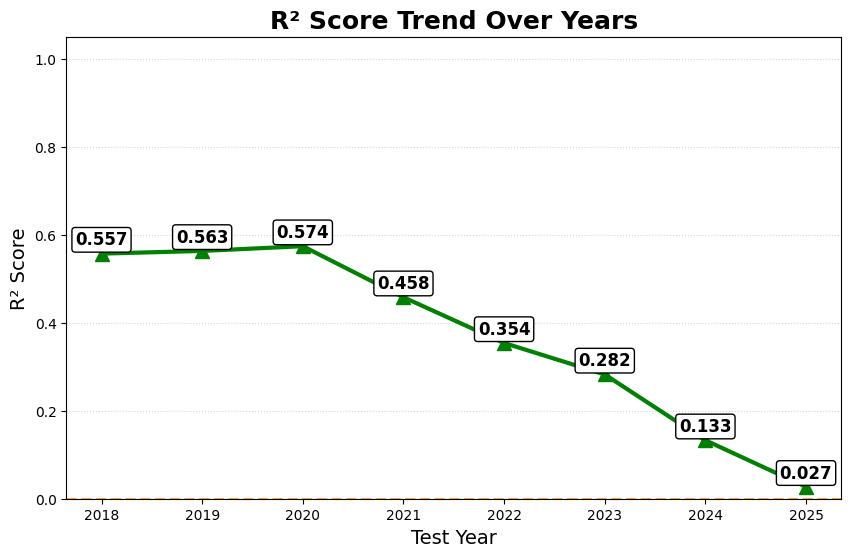

In [ ]:
import pandas as pd

# Convert to DataFrame
results_df = pd.DataFrame(all_year_results)

# Add quality rating
def get_quality(r2):
    if r2 > 0.7:
        return "EXCELLENT"
    elif r2 > 0.6:
        return "VERY GOOD"
    elif r2 > 0.5:
        return "GOOD"
    elif r2 > 0.4:
        return "FAIR"
    elif r2 > 0.3:
        return "POOR"
    else:
        return "VERY POOR"

results_df['Quality'] = results_df['R2_Score'].apply(get_quality)
results_df['Accuracy_%'] = (results_df['R2_Score'] * 100).round(1)

print("\nCOMPLETE RESULTS OF ALL 8 TESTS:")

# Display results with formatting
display_cols = ['Test', 'Train_Years', 'Test_Year', 'Accuracy_%', 'MAE_%', 'Quality']
display_df = results_df[display_cols].copy()
display_df.columns = ['Test', 'Train Years', 'Test Year', 'Accuracy %', 'Error %', 'Quality Rating']

print(display_df.to_string(index=False))

print("QUALITY SCALE EXPLANATION:")

print("EXCELLENT : R² > 0.70 (Explains >70% of price variations)")
print("VERY GOOD : R² 0.60-0.70 (Explains 60-70%)")
print("GOOD      : R² 0.50-0.60 (Explains 50-60%)")
print("FAIR      : R² 0.40-0.50 (Explains 40-50%)")
print("POOR      : R² 0.30-0.40 (Explains 30-40%)")
print("VERY POOR : R² < 0.30 (Explains <30%)")

print("KEY FINDINGS:")

# Best and worst models
best_idx = results_df['R2_Score'].idxmax()
worst_idx = results_df['R2_Score'].idxmin()

print(f"BEST PERFORMING MODEL: {results_df.loc[best_idx, 'Test']}")
print(f"  Accuracy: {results_df.loc[best_idx, 'Accuracy_%']}%")
print(f"  Quality: {results_df.loc[best_idx, 'Quality']}")

print(f"\nWORST PERFORMING MODEL: {results_df.loc[worst_idx, 'Test']}")
print(f"  Accuracy: {results_df.loc[worst_idx, 'Accuracy_%']}%")
print(f"  Quality: {results_df.loc[worst_idx, 'Quality']}")

print(f"\nAVERAGE ACCURACY across all tests: {results_df['Accuracy_%'].mean():.1f}%")
print(f"AVERAGE ERROR across all tests: {results_df['MAE_%'].mean():.1f}%")

print("TREND ANALYSIS:")

# Check if accuracy improves or worsens over time
first_acc = results_df.loc[0, 'Accuracy_%']
last_acc = results_df.loc[len(results_df)-1, 'Accuracy_%']
trend_change = ((last_acc - first_acc) / first_acc) * 100

print(f"First test (2017→2018): {first_acc}% accuracy")
print(f"Last test (2017-2024→2025): {last_acc}% accuracy")
print(f"Change: {trend_change:+.1f}%")

if trend_change > 0:
    print("Trend: Accuracy improves over time with more training data")
else:
    print("Trend: Accuracy decreases over time")

import matplotlib.pyplot as plt
import numpy as np

# Extract years and R2 values
years = results_df["Test_Year"].tolist()
r2_scores = results_df["R2_Score"].tolist()

# Baseline (optional threshold line)


plt.figure(figsize=(10, 6))

# Plot main line
plt.plot(years, r2_scores, marker='^', markersize=10, color='green', linewidth=3)

# Add annotations for each point
for x, y in zip(years, r2_scores):
    plt.text(x, y + 0.02, f"{y:.3f}", fontsize=12, fontweight='bold',
             ha='center', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black"))

# Dashed baseline at R² = 0.50
plt.axhline( color='orange', linestyle='--', linewidth=2)

# Titles and labels
plt.title("R² Score Trend Over Years", fontsize=18, fontweight='bold')
plt.xlabel("Test Year", fontsize=14)
plt.ylabel("R² Score", fontsize=14)

plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.show()


Running Different Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Function to convert remaining_lease string to years
def convert_remaining_lease(lease_str):
    if pd.isna(lease_str):
        return np.nan
    lease_str = str(lease_str)
    # Extract years and months
    years = 0
    months = 0
    if 'years' in lease_str:
        years = int(lease_str.split('years')[0].strip())
        if 'months' in lease_str:
            months = int(lease_str.split('years')[1].split('months')[0].strip())
    elif 'year' in lease_str:
        years = int(lease_str.split('year')[0].strip())
        if 'months' in lease_str:
            months = int(lease_str.split('year')[1].split('months')[0].strip())
    return years + (months / 12)

# Clean and prepare data
def prepare_data(df):
    df_clean = df.copy()

    # Extract year
    df_clean['month'] = pd.to_datetime(df_clean['month'])
    df_clean['year'] = df_clean['month'].dt.year

    # Convert remaining_lease
    df_clean['remaining_lease_years'] = df_clean['remaining_lease'].apply(convert_remaining_lease)

    # Clean storey_range (extract midpoint)
    def get_storey_midpoint(storey_str):
        if pd.isna(storey_str):
            return np.nan
        storey_str = str(storey_str)
        if 'TO' in storey_str:
            low, high = map(int, storey_str.split('TO'))
            return (low + high) / 2
        try:
            return float(storey_str)
        except:
            return np.nan

    df_clean['storey_midpoint'] = df_clean['storey_range'].apply(get_storey_midpoint)

    # Fill missing values
    numerical_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_years',
                      'storey_midpoint', 'MRT', 'Bus Stop', 'Shopping Mall',
                      'Hawker centers/food courts', 'Primary and secondary school',
                      'Kindergarten/childcare center', 'Tuition center',
                      'Polyclinic and GP Clinics', 'Community Center',
                      'degree_centrality', 'closeness_centrality',
                      'betweenness_centrality']

    for col in numerical_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    return df_clean

# Apply cleaning
df_clean = prepare_data(df_resale_price)

In [ ]:
df_estates = df_resale_price.groupby('town')[['lat', 'lon']].mean().reset_index()
df_estates.head()

,town,lat,lon
0,ANG MO KIO,1.370400,103.851103
1,BEDOK,1.332269,103.930941
2,BISHAN,1.352610,103.847285
3,BUKIT BATOK,1.347994,103.750413
4,BUKIT MERAH,1.281587,103.820859


In [ ]:
import networkx as nx
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

G = nx.Graph()

# Add all estates as nodes
for _, row in df_estates.iterrows():
    G.add_node(row['town'], lat=row['lat'], lon=row['lon'])


RADIUS = 7000  # 7 km

for i in range(len(df_estates)):
    e1 = df_estates.iloc[i]
    for j in range(i+1, len(df_estates)):
        e2 = df_estates.iloc[j]
        dist = haversine(e1['lat'], e1['lon'], e2['lat'], e2['lon'])
        if dist <= RADIUS:
            G.add_edge(e1['town'], e2['town'], weight=dist)

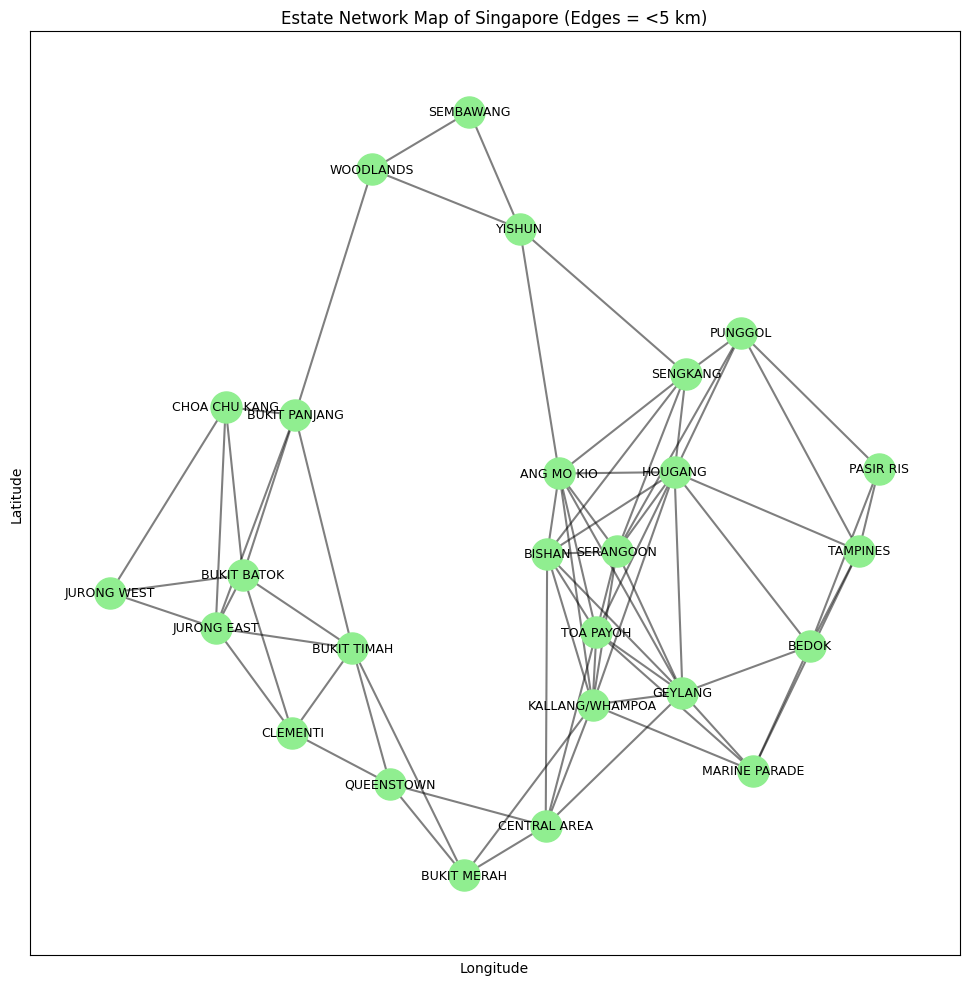

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

pos = {row['town']: (row['lon'], row['lat']) for _, row in df_estates.iterrows()}

nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightgreen')
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Estate Network Map of Singapore (Edges = <5 km)")
plt.show()

In [ ]:
# Compute centrality measures
degree_c = nx.degree_centrality(G)
closeness_c = nx.closeness_centrality(G)
betweenness_c = nx.betweenness_centrality(G, normalized=True)


# Map graph features back to df_clean
df_clean['degree_centrality'] = df_clean['town'].map(degree_c)
df_clean['closeness_centrality'] = df_clean['town'].map(closeness_c)
df_clean['betweenness_centrality'] = df_clean['town'].map(betweenness_c)

# Fill missing values
df_clean[['degree_centrality','closeness_centrality','betweenness_centrality']] = \
df_clean[['degree_centrality','closeness_centrality','betweenness_centrality']].fillna(0)

In [ ]:
centrality_df = pd.DataFrame({
    'town': degree_c.keys(),
    'degree_centrality': degree_c.values(),
    'closeness_centrality': closeness_c.values(),
    'betweenness_centrality': betweenness_c.values()
})

centrality_df.sort_values('degree_centrality', ascending=False).head(10)

,town,degree_centrality,closeness_centrality,betweenness_centrality
11,HOUGANG,0.40,0.431034,0.096138
10,GEYLANG,0.36,0.438596,0.076376
14,KALLANG/WHAMPOA,0.36,0.480769,0.196252
21,SERANGOON,0.32,0.416667,0.026321
0,ANG MO KIO,0.32,0.438596,0.092833
23,TOA PAYOH,0.32,0.423729,0.023201
2,BISHAN,0.32,0.423729,0.030484
7,CENTRAL AREA,0.24,0.423729,0.134376
6,BUKIT TIMAH,0.24,0.390625,0.205134
3,BUKIT BATOK,0.24,0.324675,0.052706


In [ ]:
centrality_df.sort_values('betweenness_centrality', ascending=False).head(10)

,town,degree_centrality,closeness_centrality,betweenness_centrality
6,BUKIT TIMAH,0.24,0.390625,0.205134
14,KALLANG/WHAMPOA,0.36,0.480769,0.196252
4,BUKIT MERAH,0.16,0.431034,0.187844
25,YISHUN,0.16,0.403226,0.157256
7,CENTRAL AREA,0.24,0.423729,0.134376
5,BUKIT PANJANG,0.20,0.347222,0.123564
24,WOODLANDS,0.12,0.367647,0.115351
11,HOUGANG,0.40,0.431034,0.096138
0,ANG MO KIO,0.32,0.438596,0.092833
18,QUEENSTOWN,0.16,0.384615,0.088995


In [ ]:
centrality_df.sort_values('closeness_centrality', ascending=False).head(10)


,town,degree_centrality,closeness_centrality,betweenness_centrality
14,KALLANG/WHAMPOA,0.36,0.480769,0.196252
0,ANG MO KIO,0.32,0.438596,0.092833
10,GEYLANG,0.36,0.438596,0.076376
11,HOUGANG,0.40,0.431034,0.096138
4,BUKIT MERAH,0.16,0.431034,0.187844
7,CENTRAL AREA,0.24,0.423729,0.134376
23,TOA PAYOH,0.32,0.423729,0.023201
2,BISHAN,0.32,0.423729,0.030484
21,SERANGOON,0.32,0.416667,0.026321
20,SENGKANG,0.24,0.409836,0.076710


In [ ]:
# for feature colums must add the 3 new features



# Ensure we have the data prepared
# df_clean = prepare_data(df_resale_price)

# Readd the graph network
df_clean['degree_centrality'] = df_clean['town'].map(degree_c)
df_clean['closeness_centrality'] = df_clean['town'].map(closeness_c)
df_clean['betweenness_centrality'] = df_clean['town'].map(betweenness_c)

df_clean[['degree_centrality','closeness_centrality','betweenness_centrality']] = \
df_clean[['degree_centrality','closeness_centrality','betweenness_centrality']].fillna(0)

print(df_clean[['town','degree_centrality','closeness_centrality','betweenness_centrality']].head())

# Define features and target
feature_cols = [
    'floor_area_sqm', 'lease_commence_date', 'remaining_lease_years',
    'storey_midpoint', 'MRT', 'Bus Stop', 'Shopping Mall',
    'Hawker centers/food courts', 'Primary and secondary school',
    'Kindergarten/childcare center', 'Tuition center',
    'Polyclinic and GP Clinics', 'Community Center', 'lat', 'lon',
    'degree_centrality', 'closeness_centrality', 'betweenness_centrality'
]

         town  degree_centrality  closeness_centrality  betweenness_centrality
0  ANG MO KIO               0.32              0.438596                0.092833
1  ANG MO KIO               0.32              0.438596                0.092833
2  ANG MO KIO               0.32              0.438596                0.092833
3  ANG MO KIO               0.32              0.438596                0.092833
4  ANG MO KIO               0.32              0.438596                0.092833


RANDOM FOREST REGRESSOR - EXPANDING WINDOW ANALYSIS

Training on years: [2017] → Testing on: 2018
Training samples: 20,509
Testing samples: 21,561
MAE: $32,733
RMSE: $43,896
R² Score: 0.9224
Average error: 7.4% of actual price
--------------------------------------------------

Training on years: [2017, 2018] → Testing on: 2019
Training samples: 42,070
Testing samples: 22,186
MAE: $34,062
RMSE: $46,092
R² Score: 0.9104
Average error: 7.9% of actual price
--------------------------------------------------

Training on years: [2017, 2018, 2019] → Testing on: 2020
Training samples: 64,256
Testing samples: 23,333
MAE: $32,731
RMSE: $46,396
R² Score: 0.9098
Average error: 7.2% of actual price
--------------------------------------------------

Training on years: [2017, 2018, 2019, 2020] → Testing on: 2021
Training samples: 87,589
Testing samples: 29,087
MAE: $52,323
RMSE: $66,199
R² Score: 0.8343
Average error: 10.2% of actual price
--------------------------------------------------

Traini

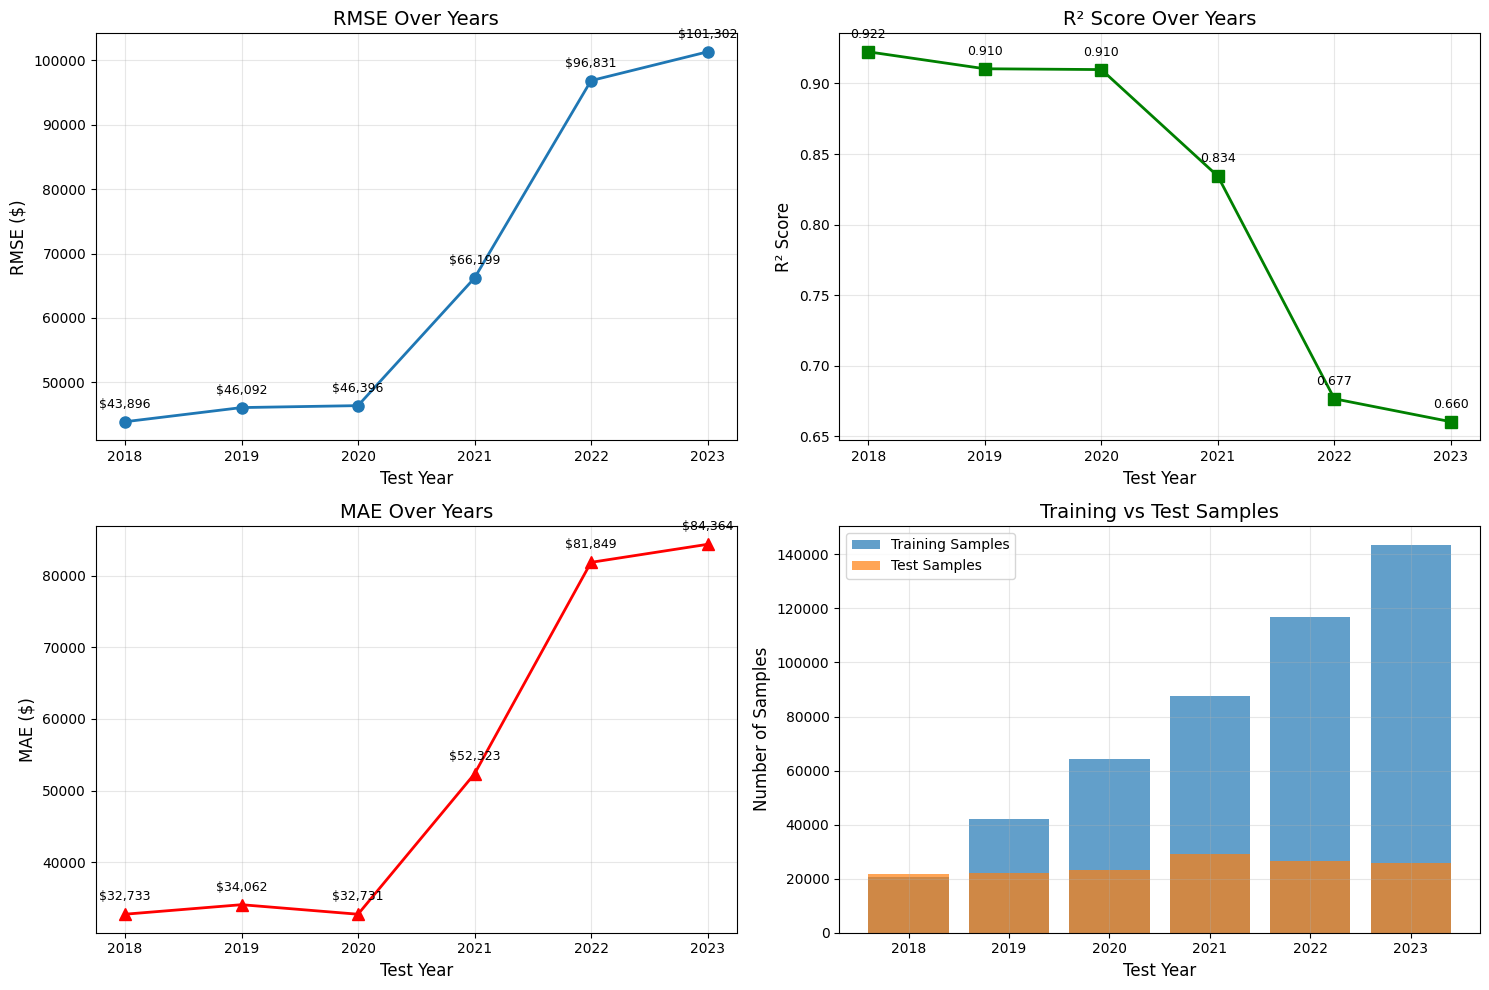

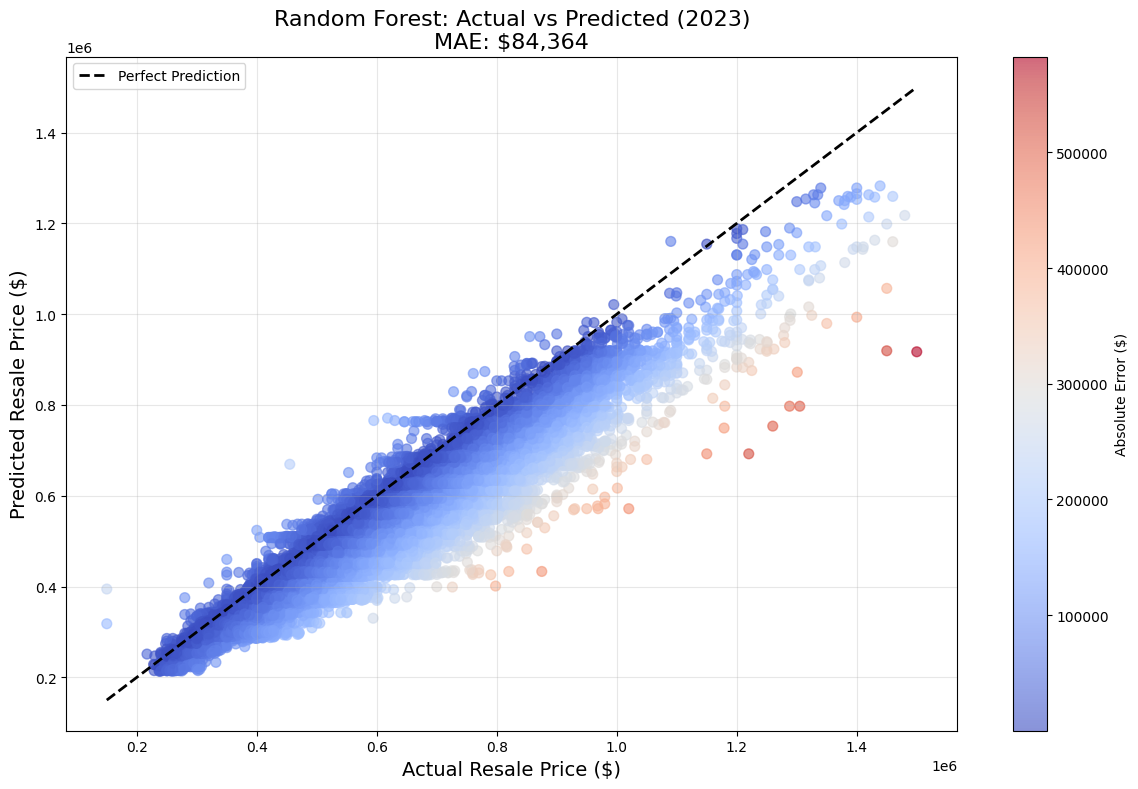

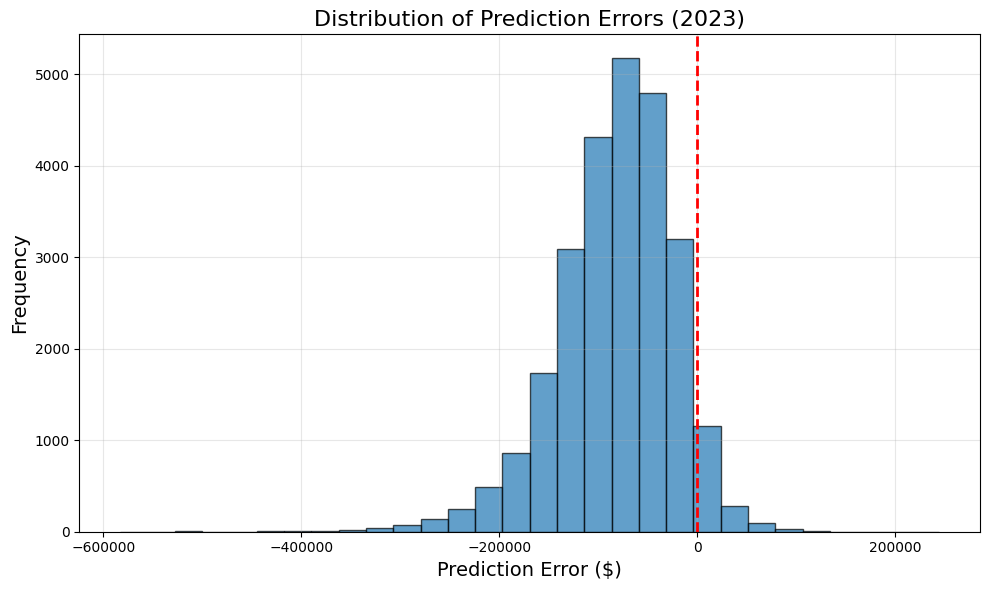


FEATURE IMPORTANCE (Final Model Trained on 2017-2022)

Top 20 Most Important Features:
--------------------------------------------------
floor_area_sqm                                     0.5185
lat                                                0.1764
lease_commence_date                                0.1018
lon                                                0.0331
closeness_centrality                               0.0276
degree_centrality                                  0.0249
storey_midpoint                                    0.0200
flat_model_DBSS                                    0.0185
remaining_lease_years                              0.0146
flat_model_Model A                                 0.0119
town_BISHAN                                        0.0115
town_TOA PAYOH                                     0.0036
MRT                                                0.0034
flat_type_5 ROOM                                   0.0031
Polyclinic and GP Clinics                        

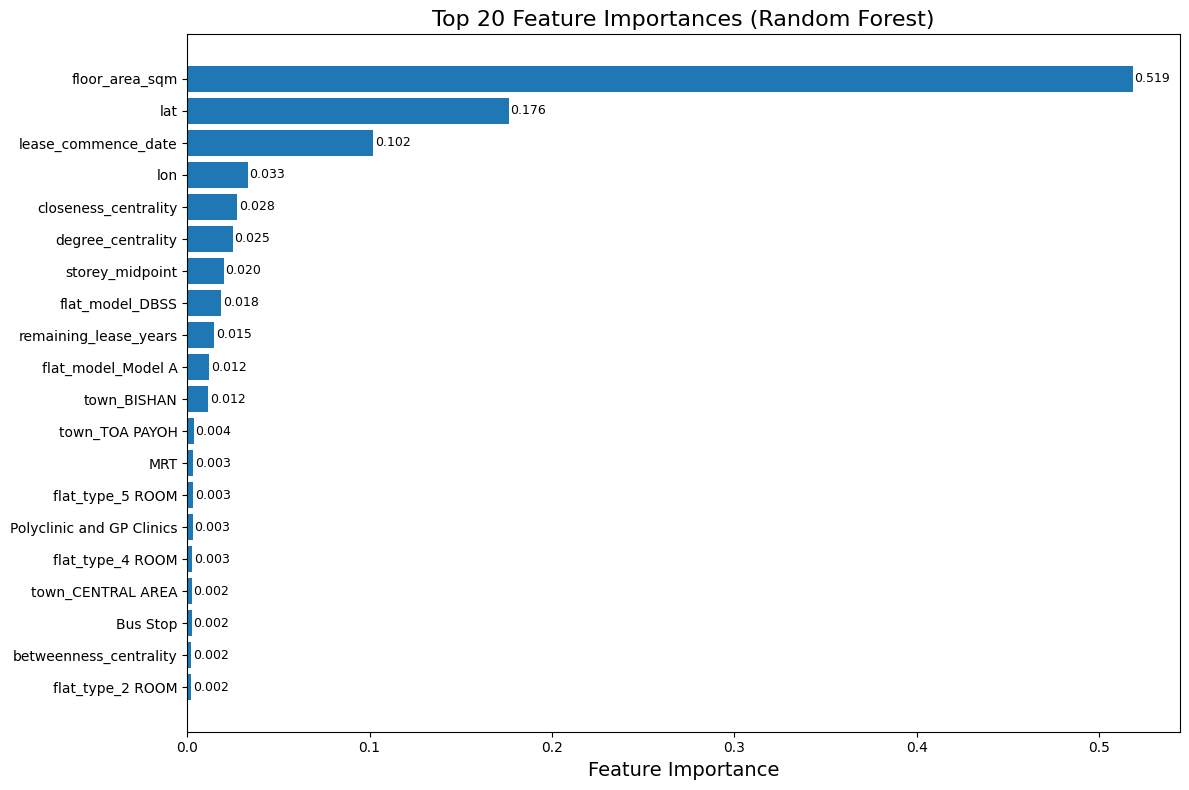


PERFORMANCE SUMMARY
Average RMSE across all years: $66,786
Average MAE across all years: $53,011
Average R² across all years: 0.8190
Best R² score: 0.9224 in 2018
Worst R² score: 0.6604 in 2023


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Ensure we have the data prepared
# df_clean = prepare_data(df_resale_price)

# Define features and target
feature_cols = [
    'floor_area_sqm', 'lease_commence_date', 'remaining_lease_years',
    'storey_midpoint', 'MRT', 'Bus Stop', 'Shopping Mall',
    'Hawker centers/food courts', 'Primary and secondary school',
    'Kindergarten/childcare center', 'Tuition center',
    'Polyclinic and GP Clinics', 'Community Center', 'lat', 'lon',
                      'degree_centrality', 'closeness_centrality',
                      'betweenness_centrality']

categorical_cols = ['town', 'flat_type', 'flat_model']
all_features = feature_cols + categorical_cols
target_col = 'resale_price'

# Create lists to store results
results = {
    'train_years': [],
    'test_year': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'train_samples': [],
    'test_samples': []
}

# Define the expanding window training strategy
start_year = 2017
end_year = 2023

print("="*70)
print("RANDOM FOREST REGRESSOR - EXPANDING WINDOW ANALYSIS")
print("="*70)

# Create preprocessing pipeline (to be used in each iteration)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), feature_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Create pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

# Perform expanding window analysis
for test_year in range(2018, end_year + 1):
    # Training data: all years before test_year
    train_years = list(range(start_year, test_year))

    # Get training and testing data
    train_mask = df_clean['year'].isin(train_years)
    test_mask = df_clean['year'] == test_year

    X_train = df_clean[train_mask][all_features]
    y_train = df_clean[train_mask][target_col]
    X_test = df_clean[test_mask][all_features]
    y_test = df_clean[test_mask][target_col]

    # Check if we have data for this year
    if len(X_test) == 0:
        print(f"Skipping {test_year}: No test data available")
        continue

    print(f"\nTraining on years: {train_years} → Testing on: {test_year}")
    print(f"Training samples: {len(X_train):,}")
    print(f"Testing samples: {len(X_test):,}")

    # Train model
    rf_pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = rf_pipeline.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    results['train_years'].append(f"{train_years[0]}-{train_years[-1]}")
    results['test_year'].append(test_year)
    results['mae'].append(mae)
    results['rmse'].append(rmse)
    results['r2'].append(r2)
    results['train_samples'].append(len(X_train))
    results['test_samples'].append(len(X_test))

    # Print results for this iteration
    print(f"MAE: ${mae:,.0f}")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Average error: {mae/y_test.mean()*100:.1f}% of actual price")
    print("-" * 50)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("SUMMARY OF ALL ITERATIONS")
print("="*70)
print(results_df.to_string(index=False))

# Plot accuracy metrics over time
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: RMSE over years
axes[0, 0].plot(results_df['test_year'], results_df['rmse'], marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Test Year', fontsize=12)
axes[0, 0].set_ylabel('RMSE ($)', fontsize=12)
axes[0, 0].set_title('RMSE Over Years', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].ticklabel_format(style='plain', axis='y')

# Annotate RMSE values
for i, row in results_df.iterrows():
    axes[0, 0].annotate(f"${row['rmse']:,.0f}",
                       (row['test_year'], row['rmse']),
                       textcoords="offset points", xytext=(0,10),
                       ha='center', fontsize=9)

# Plot 2: R² Score over years
axes[0, 1].plot(results_df['test_year'], results_df['r2'], marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Test Year', fontsize=12)
axes[0, 1].set_ylabel('R² Score', fontsize=12)
axes[0, 1].set_title('R² Score Over Years', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Annotate R² values
for i, row in results_df.iterrows():
    axes[0, 1].annotate(f"{row['r2']:.3f}",
                       (row['test_year'], row['r2']),
                       textcoords="offset points", xytext=(0,10),
                       ha='center', fontsize=9)

# Plot 3: MAE over years
axes[1, 0].plot(results_df['test_year'], results_df['mae'], marker='^', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Test Year', fontsize=12)
axes[1, 0].set_ylabel('MAE ($)', fontsize=12)
axes[1, 0].set_title('MAE Over Years', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].ticklabel_format(style='plain', axis='y')

# Annotate MAE values
for i, row in results_df.iterrows():
    axes[1, 0].annotate(f"${row['mae']:,.0f}",
                       (row['test_year'], row['mae']),
                       textcoords="offset points", xytext=(0,10),
                       ha='center', fontsize=9)

# Plot 4: Sample sizes
axes[1, 1].bar(results_df['test_year'], results_df['train_samples'], alpha=0.7, label='Training Samples')
axes[1, 1].bar(results_df['test_year'], results_df['test_samples'], alpha=0.7, label='Test Samples')
axes[1, 1].set_xlabel('Test Year', fontsize=12)
axes[1, 1].set_ylabel('Number of Samples', fontsize=12)
axes[1, 1].set_title('Training vs Test Samples', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: Plot actual vs predicted for the last year (2023)
if 2023 in results_df['test_year'].values:
    # Get data for 2023
    test_mask_2023 = df_clean['year'] == 2023
    X_test_2023 = df_clean[test_mask_2023][all_features]
    y_test_2023 = df_clean[test_mask_2023][target_col]

    # Use the last trained model (trained on 2017-2022)
    y_pred_2023 = rf_pipeline.predict(X_test_2023)

    # Create detailed scatter plot for 2023
    plt.figure(figsize=(12, 8))

    # Calculate error bounds
    error = y_pred_2023 - y_test_2023
    mae_2023 = mean_absolute_error(y_test_2023, y_pred_2023)

    # Scatter plot with color based on error magnitude
    scatter = plt.scatter(y_test_2023, y_pred_2023,
                         c=np.abs(error),
                         cmap='coolwarm',
                         alpha=0.6,
                         s=50)

    # Perfect prediction line
    plt.plot([y_test_2023.min(), y_test_2023.max()],
             [y_test_2023.min(), y_test_2023.max()],
             'k--', lw=2, label='Perfect Prediction')

    # Add colorbar
    plt.colorbar(scatter, label='Absolute Error ($)')

    plt.xlabel('Actual Resale Price ($)', fontsize=14)
    plt.ylabel('Predicted Resale Price ($)', fontsize=14)
    plt.title(f'Random Forest: Actual vs Predicted (2023)\nMAE: ${mae_2023:,.0f}', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Distribution of errors
    plt.figure(figsize=(10, 6))
    plt.hist(error, bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
    plt.xlabel('Prediction Error ($)', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('Distribution of Prediction Errors (2023)', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Feature importance from the final model (trained on 2017-2022)
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Final Model Trained on 2017-2022)")
print("="*70)

# Get feature names from the preprocessor
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']
feature_names = list(feature_cols)

# Get one-hot encoded categorical feature names
cat_encoder = preprocessor_fitted.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)

# Combine all feature names
all_feature_names = feature_names + cat_feature_names.tolist()

# Get feature importances
importances = rf_model.feature_importances_

# Create DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

print("\nTop 20 Most Important Features:")
print("-" * 50)
for i, row in feature_importance_df.iterrows():
    print(f"{row['feature']:50} {row['importance']:.4f}")

# Plot top features
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(feature_importance_df)),
                feature_importance_df['importance'].values)
plt.yticks(range(len(feature_importance_df)),
           feature_importance_df['feature'].values)
plt.xlabel('Feature Importance', fontsize=14)
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=16)
plt.gca().invert_yaxis()

# Add value labels
for i, (bar, importance) in enumerate(zip(bars, feature_importance_df['importance'].values)):
    plt.text(importance + 0.001, bar.get_y() + bar.get_height()/2,
             f'{importance:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("PERFORMANCE SUMMARY")
print("="*70)
print(f"Average RMSE across all years: ${results_df['rmse'].mean():,.0f}")
print(f"Average MAE across all years: ${results_df['mae'].mean():,.0f}")
print(f"Average R² across all years: {results_df['r2'].mean():.4f}")
print(f"Best R² score: {results_df['r2'].max():.4f} in {results_df.loc[results_df['r2'].idxmax(), 'test_year']}")
print(f"Worst R² score: {results_df['r2'].min():.4f} in {results_df.loc[results_df['r2'].idxmin(), 'test_year']}")

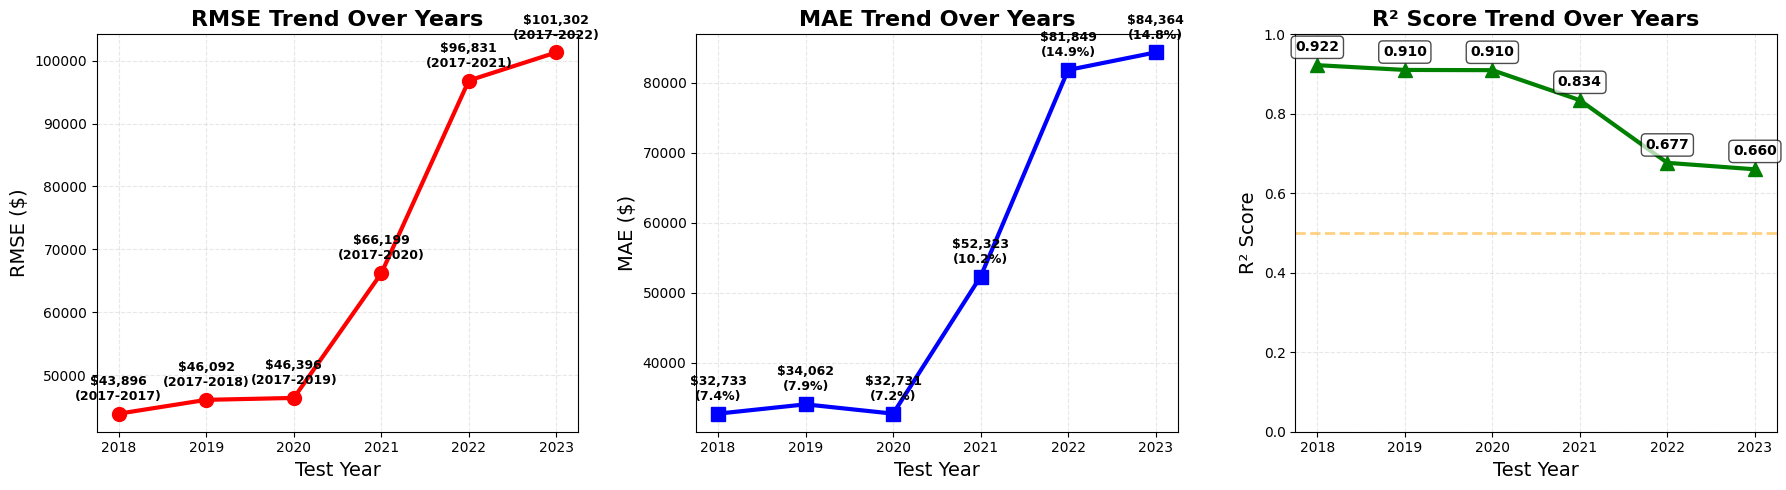


MODEL PERFORMANCE SUMMARY (Random Forest - Expanding Window)
 test_year train_years  train_samples  test_samples     rmse     mae    r2 % Error
      2018   2017-2017          20509         21561  $43,896 $32,733 0.922    7.4%
      2019   2017-2018          42070         22186  $46,092 $34,062 0.910    7.9%
      2020   2017-2019          64256         23333  $46,396 $32,731 0.910    7.2%
      2021   2017-2020          87589         29087  $66,199 $52,323 0.834   10.2%
      2022   2017-2021         116676         26720  $96,831 $81,849 0.677   14.9%
      2023   2017-2022         143396         25754 $101,302 $84,364 0.660   14.8%

KEY INSIGHTS
1. Best Performance: 2018 (R² = 0.922)
2. Worst Performance: 2023 (R² = 0.660)
3. Average R² across all years: 0.819
4. Average MAE: $53,011
5. Average RMSE: $66,786
6. Model stability: R² ranges from 0.660 to 0.922


In [ ]:
# Create a clean figure with only RMSE, MAE, and R² trends
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: RMSE over years
axes[0].plot(results_df['test_year'], results_df['rmse'], marker='o', linewidth=3, markersize=10, color='red')
axes[0].set_xlabel('Test Year', fontsize=14)
axes[0].set_ylabel('RMSE ($)', fontsize=14)
axes[0].set_title('RMSE Trend Over Years', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].ticklabel_format(style='plain', axis='y')

# Annotate RMSE values with training years
for i, row in results_df.iterrows():
    axes[0].annotate(f"${row['rmse']:,.0f}\n({row['train_years']})",
                    (row['test_year'], row['rmse']),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=9, fontweight='bold')

# Plot 2: MAE over years
axes[1].plot(results_df['test_year'], results_df['mae'], marker='s', linewidth=3, markersize=10, color='blue')
axes[1].set_xlabel('Test Year', fontsize=14)
axes[1].set_ylabel('MAE ($)', fontsize=14)
axes[1].set_title('MAE Trend Over Years', fontsize=16, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].ticklabel_format(style='plain', axis='y')

# Annotate MAE values with percentage error
for i, row in results_df.iterrows():
    # Calculate percentage error for this year
    test_mask = df_clean['year'] == row['test_year']
    actual_mean = df_clean[test_mask]['resale_price'].mean()
    percentage_error = (row['mae'] / actual_mean) * 100
    axes[1].annotate(f"${row['mae']:,.0f}\n({percentage_error:.1f}%)",
                    (row['test_year'], row['mae']),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=9, fontweight='bold')

# Plot 3: R² over years
axes[2].plot(results_df['test_year'], results_df['r2'], marker='^', linewidth=3, markersize=10, color='green')
axes[2].set_xlabel('Test Year', fontsize=14)
axes[2].set_ylabel('R² Score', fontsize=14)
axes[2].set_title('R² Score Trend Over Years', fontsize=16, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_ylim([0, 1])  # R² typically between 0 and 1

# Annotate R² values
for i, row in results_df.iterrows():
    axes[2].annotate(f"{row['r2']:.3f}",
                    (row['test_year'], row['r2']),
                    textcoords="offset points", xytext=(0,10),
                    ha='center', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Add horizontal line at R²=0.5 for reference
axes[2].axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, linewidth=2)

plt.tight_layout()
plt.show()

# Print a summary table
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY (Random Forest - Expanding Window)")
print("="*80)

summary_table = results_df[['test_year', 'train_years', 'train_samples', 'test_samples',
                           'rmse', 'mae', 'r2']].copy()

# Add percentage error column
summary_table['% Error'] = summary_table.apply(lambda row:
    (row['mae'] / df_clean[df_clean['year'] == row['test_year']]['resale_price'].mean()) * 100,
    axis=1)

summary_table['% Error'] = summary_table['% Error'].round(1)

# Format the table nicely
summary_table_display = summary_table.copy()
summary_table_display['rmse'] = summary_table_display['rmse'].apply(lambda x: f"${x:,.0f}")
summary_table_display['mae'] = summary_table_display['mae'].apply(lambda x: f"${x:,.0f}")
summary_table_display['r2'] = summary_table_display['r2'].apply(lambda x: f"{x:.3f}")
summary_table_display['% Error'] = summary_table_display['% Error'].apply(lambda x: f"{x:.1f}%")

print(summary_table_display.to_string(index=False))

# Print key insights
print("KEY INSIGHTS")
print(f"1. Best Performance: {summary_table.loc[summary_table['r2'].idxmax(), 'test_year']} "
      f"(R² = {summary_table['r2'].max():.3f})")
print(f"2. Worst Performance: {summary_table.loc[summary_table['r2'].idxmin(), 'test_year']} "
      f"(R² = {summary_table['r2'].min():.3f})")
print(f"3. Average R² across all years: {summary_table['r2'].mean():.3f}")
print(f"4. Average MAE: ${summary_table['mae'].mean():,.0f}")
print(f"5. Average RMSE: ${summary_table['rmse'].mean():,.0f}")
print(f"6. Model stability: R² ranges from {summary_table['r2'].min():.3f} to {summary_table['r2'].max():.3f}")

HDB RESALE MARKET NETWORK ANALYSIS

1. CREATING TOWN NETWORK BASED ON PRICE SIMILARITY
   Network created: 26 towns, 243 connections
   Average connections per town: 9.3

2. CENTRALITY METRICS ANALYSIS

   TOP 5 TOWNS BY DEGREE CENTRALITY (most connected):
   • CLEMENTI: 0.920
   • MARINE PARADE: 0.920
   • TAMPINES: 0.920
   • TOA PAYOH: 0.920
   • HOUGANG: 0.880

   TOP 5 TOWNS BY BETWEENNESS CENTRALITY (key bridges):
   • TOA PAYOH: 0.037
   • PASIR RIS: 0.031
   • BUKIT MERAH: 0.030
   • QUEENSTOWN: 0.030
   • KALLANG/WHAMPOA: 0.028

   TOP 5 TOWNS BY CLOSENESS CENTRALITY (most accessible):
   • CLEMENTI: 0.926
   • MARINE PARADE: 0.926
   • TAMPINES: 0.926
   • TOA PAYOH: 0.926
   • HOUGANG: 0.893

3. PAGERANK ANALYSIS

   TOP 5 TOWNS BY PAGERANK (influence in the network):
   • TOA PAYOH: 0.0461
   • CLEMENTI: 0.0458
   • MARINE PARADE: 0.0457
   • TAMPINES: 0.0457
   • HOUGANG: 0.0442

4. NETWORK CLUSTERING ANALYSIS
   Average clustering coefficient: 0.894

   TOP 5 TOWNS BY CLU

<Figure size 1400x1000 with 0 Axes>

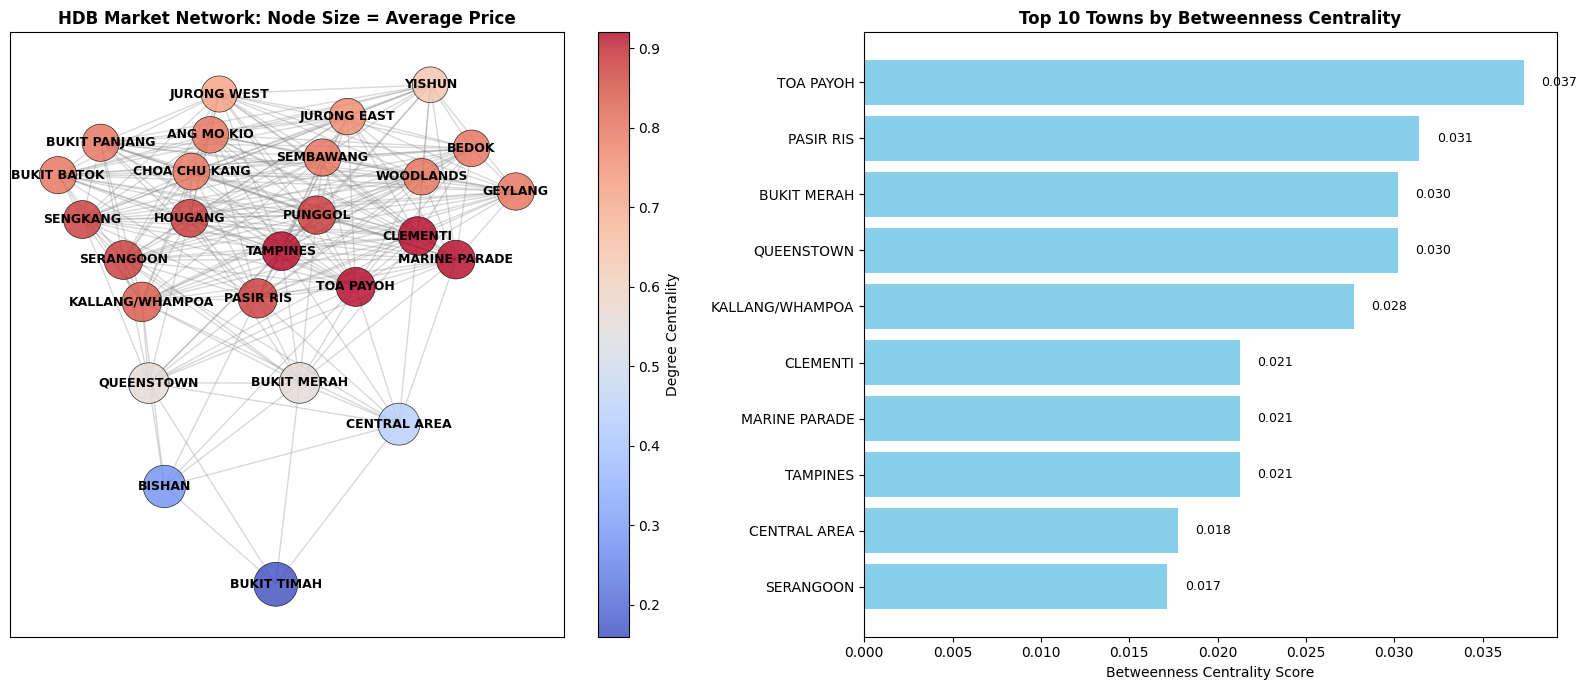


8. INTEGRATION WITH EXISTING ML ANALYSIS

   NETWORK METRICS FOR KEY TOWNS:

   TOA PAYOH (Key Bridge Town):
      • Betweenness: 0.037
      • Degree: 0.920
      • Avg Price: SGD 567,821

   PASIR RIS (Key Bridge Town):
      • Betweenness: 0.031
      • Degree: 0.880
      • Avg Price: SGD 581,215

   BUKIT MERAH (Key Bridge Town):
      • Betweenness: 0.030
      • Degree: 0.560
      • Avg Price: SGD 635,514


In [ ]:
# NETWORK ANALYSIS OF HDB MARKET USING GRAPH THEORY

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("HDB RESALE MARKET NETWORK ANALYSIS")

# 1. Create town similarity network based on average prices
print("\n1. CREATING TOWN NETWORK BASED ON PRICE SIMILARITY")

# Calculate average price per town
town_avg_price = df_resale_price.groupby('town')['resale_price'].mean()

# Create graph
G = nx.Graph()

# Add towns as nodes
for town, avg_price in town_avg_price.items():
    G.add_node(town, avg_price=avg_price)

# Add edges between towns with similar prices (within 20% difference)
edge_count = 0
towns = list(town_avg_price.index)

for i in range(len(towns)):
    for j in range(i + 1, len(towns)):
        town1, town2 = towns[i], towns[j]
        price1, price2 = town_avg_price[town1], town_avg_price[town2]

        # Calculate price similarity
        price_ratio = min(price1, price2) / max(price1, price2)

        if price_ratio > 0.8:  # Prices within 20% of each other
            G.add_edge(town1, town2, weight=price_ratio)
            edge_count += 1

print(f"   Network created: {G.number_of_nodes()} towns, {G.number_of_edges()} connections")
print(f"   Average connections per town: {G.number_of_edges() / G.number_of_nodes():.1f}")

# 2. Calculate centrality metrics
print("\n2. CENTRALITY METRICS ANALYSIS")

# Degree centrality
degree_centrality = nx.degree_centrality(G)
print("\n   TOP 5 TOWNS BY DEGREE CENTRALITY (most connected):")
sorted_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
for town, centrality in sorted_degree:
    print(f"   • {town}: {centrality:.3f}")

# Betweenness centrality
betweenness = nx.betweenness_centrality(G)
print("\n   TOP 5 TOWNS BY BETWEENNESS CENTRALITY (key bridges):")
sorted_between = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
for town, centrality in sorted_between:
    print(f"   • {town}: {centrality:.3f}")

# Closeness centrality
closeness = nx.closeness_centrality(G)
print("\n   TOP 5 TOWNS BY CLOSENESS CENTRALITY (most accessible):")
sorted_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:5]
for town, centrality in sorted_closeness:
    print(f"   • {town}: {centrality:.3f}")

# 3. PageRank analysis
print("\n3. PAGERANK ANALYSIS")

pagerank = nx.pagerank(G, alpha=0.85)
print("\n   TOP 5 TOWNS BY PAGERANK (influence in the network):")
sorted_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
for town, score in sorted_pagerank:
    print(f"   • {town}: {score:.4f}")

# 4. Network clustering analysis
print("\n4. NETWORK CLUSTERING ANALYSIS")

# Calculate clustering coefficient for each town
clustering_coeff = nx.clustering(G)
avg_clustering = nx.average_clustering(G)

print(f"   Average clustering coefficient: {avg_clustering:.3f}")
print("\n   TOP 5 TOWNS BY CLUSTERING COEFFICIENT (form tight local groups):")
sorted_clustering = sorted(clustering_coeff.items(), key=lambda x: x[1], reverse=True)[:5]
for town, coeff in sorted_clustering:
    print(f"   • {town}: {coeff:.3f}")

# 5. Find network hubs and authorities
print("\n5. NETWORK HUBS AND AUTHORITIES ANALYSIS")

try:
    # Hubs and authorities (HITS algorithm)
    hubs, authorities = nx.hits(G, max_iter=100)

    print("\n   TOP 5 HUBS (towns that link to important towns):")
    sorted_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:5]
    for town, score in sorted_hubs:
        print(f"   • {town}: {score:.4f}")

    print("\n   TOP 5 AUTHORITIES (important towns that are linked to):")
    sorted_auth = sorted(authorities.items(), key=lambda x: x[1], reverse=True)[:5]
    for town, score in sorted_auth:
        print(f"   • {town}: {score:.4f}")

except Exception as e:
    print(f"   HITS algorithm not available: {e}")

# 6. Network statistics summary
print("\n6. NETWORK STATISTICS SUMMARY")
print("-" * 40)

print(f"   • Number of nodes (towns): {G.number_of_nodes()}")
print(f"   • Number of edges (connections): {G.number_of_edges()}")
print(f"   • Network density: {nx.density(G):.3f}")
print(f"   • Is connected: {'Yes' if nx.is_connected(G) else 'No'}")
print(f"   • Average shortest path length: {nx.average_shortest_path_length(G):.2f}")

# 7. NETWORK VISUALIZATION WITH PRICE INFORMATION
print("\n7. NETWORK VISUALIZATION WITH PRICE INFORMATION")

plt.figure(figsize=(14, 10))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Network with node size = average price
ax1.set_title("HDB Market Network: Node Size = Average Price", fontsize=12, fontweight='bold')

# Fix: Get max price properly
if hasattr(town_avg_price, 'values'):
    max_price_value = max(town_avg_price.values)
else:
    max_price_value = max(town_avg_price)

# Node size based on average price (normalized)
node_sizes = []
for town in G.nodes():
    if hasattr(town_avg_price, 'get'):
        price = town_avg_price.get(town, max_price_value)
    else:
        # If town_avg_price is a Series
        price = town_avg_price[town]
    size = 200 + (price / max_price_value * 800)
    node_sizes.append(size)

# Node color based on degree centrality
node_colors = [degree_centrality[town] for town in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=0.5)
nodes = nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=node_sizes,
                               node_color=node_colors, cmap='coolwarm',
                               alpha=0.8, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.3, edge_color='gray')
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=9, font_weight='bold')

# Add colorbar for degree centrality
plt.colorbar(nodes, ax=ax1, label='Degree Centrality')

# Plot 2: Bar chart of top towns by betweenness centrality
ax2.set_title("Top 10 Towns by Betweenness Centrality", fontsize=12, fontweight='bold')

# Use the betweenness data we already calculated
top_betweenness_for_chart = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
towns_names = [town for town, _ in top_betweenness_for_chart]
betweenness_values = [value for _, value in top_betweenness_for_chart]

bars = ax2.barh(towns_names, betweenness_values, color='skyblue')
ax2.set_xlabel('Betweenness Centrality Score')
ax2.invert_yaxis()  # Highest value at top

# Add value labels on bars
for bar, value in zip(bars, betweenness_values):
    width = bar.get_width()
    ax2.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 8. Integration with ML models
print("\n8. INTEGRATION WITH EXISTING ML ANALYSIS")

# Create a DataFrame with network metrics for each town
network_metrics = pd.DataFrame({
    'town': list(G.nodes()),
    'degree_centrality': [degree_centrality[town] for town in G.nodes()],
    'betweenness_centrality': [betweenness[town] for town in G.nodes()],
    'closeness_centrality': [closeness[town] for town in G.nodes()],
    'pagerank': [pagerank[town] for town in G.nodes()],
    'clustering_coeff': [clustering_coeff[town] for town in G.nodes()],
    'avg_price': [town_avg_price[town] for town in G.nodes()]
})

print("\n   NETWORK METRICS FOR KEY TOWNS:")

# Show metrics for towns with highest betweenness (key bridges)
key_towns = network_metrics.nlargest(3, 'betweenness_centrality')
for idx, row in key_towns.iterrows():
    print(f"\n   {row['town']} (Key Bridge Town):")
    print(f"      • Betweenness: {row['betweenness_centrality']:.3f}")
    print(f"      • Degree: {row['degree_centrality']:.3f}")
    print(f"      • Avg Price: SGD {row['avg_price']:,.0f}")


In [ ]:
!pip install streamlit pyngrok streamlit-folium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.6/524.6 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 41.0 MB/s eta 0:00:00


In [ ]:
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 5s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [ ]:
!streamlit run dashboard.py --server.port=8501 --server.address=0.0.0.0 &


Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: dashboard.py


In [ ]:
!lt --port 8501


In [ ]:
%%writefile forecast_utils.py
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import streamlit as st


# -----------------------------
# Train model up to specific year
# -----------------------------
@st.cache_resource
def get_trained_model(df, feature_cols, categorical_cols, target_col, last_train_year):
    train_df = df[df['year'] <= last_train_year].copy()

    X_train = train_df[feature_cols + categorical_cols]
    y_train = train_df[target_col]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), feature_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ]
    )

    model = RandomForestRegressor(
        n_estimators=120,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)

    return pipeline


# -----------------------------
# Predict for ONE future year
# -----------------------------
@st.cache_data
def predict_for_year(df, _model, feature_cols, categorical_cols, target_col, base_year, future_year):
    gap = future_year - base_year

    base_df = df[df['year'] == base_year].copy()
    if base_df.empty:
        raise ValueError(f"No data for base_year={base_year}")

    # Adjust remaining lease
    if "remaining_lease_years" in base_df.columns:
        base_df["remaining_lease_years"] = (base_df["remaining_lease_years"] - gap).clip(lower=0)

    X_future = base_df[feature_cols + categorical_cols]
    predictions = _model.predict(X_future)
    base_df["predicted_price"] = predictions

    # Aggregate by town
    town_pred = (
      base_df.dropna(subset=["lat", "lon"])
      .groupby(["town", "flat_type"])
      .agg(predicted_price=("predicted_price", "mean"),
          lat=("lat", "mean"),
          lon=("lon", "mean"),
          flats_used=("resale_price", "size"))
      .reset_index()
    )

    town_pred["future_year"] = future_year
    return town_pred


# -----------------------------
# Predict for a RANGE of years
# -----------------------------
@st.cache_data
def build_forecast_range(df, feature_cols, categorical_cols, target_col, start_year, end_year):
    last_real_year = df["year"].max()
    model = get_trained_model(df, feature_cols, categorical_cols, target_col, last_real_year)

    all_years = []
    for year in range(start_year, end_year + 1):
        pred = predict_for_year(df, model, feature_cols, categorical_cols, target_col, last_real_year, year)
        all_years.append(pred)

    return pd.concat(all_years, ignore_index=True)


Overwriting forecast_utils.py


In [ ]:
%%writefile config.py
feature_cols = [
    'floor_area_sqm', 'lease_commence_date', 'remaining_lease_years',
    'storey_midpoint', 'MRT', 'Bus Stop', 'Shopping Mall',
    'Hawker centers/food courts', 'Primary and secondary school',
    'Kindergarten/childcare center', 'Tuition center',
    'Polyclinic and GP Clinics', 'Community Center', 'lat', 'lon',
                      'degree_centrality', 'closeness_centrality',
                      'betweenness_centrality']

categorical_cols = ['town', 'flat_type', 'flat_model']

target_col = "resale_price"


Overwriting config.py


In [ ]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import folium
from streamlit.components.v1 import html   # stable map rendering

from config import feature_cols, categorical_cols, target_col
from forecast_utils import get_trained_model, predict_for_year


# -----------------------------
# Load and prepare data
# -----------------------------
df_clean = pd.read_csv("df_clean.csv")
last_real_year = int(df_clean["year"].max())
future_min = last_real_year + 1
future_max = last_real_year + 10

st.set_page_config(page_title="HDB Forecast Dashboard", layout="wide")
st.title("Singapore HDB Resale Price Forecast Dashboard")


# -----------------------------
# Sidebar Controls
# -----------------------------
st.sidebar.header("Controls")

year_choice = st.sidebar.slider(
    "Select future year to forecast",
    min_value=future_min,
    max_value=future_max,
    value=future_min
)

# Town filter
towns = sorted(df_clean["town"].unique())
selected_towns = st.sidebar.multiselect("Filter towns", towns, default=towns)

# NEW — flat type filter
flat_types = sorted(df_clean["flat_type"].unique())
selected_flat_types = st.sidebar.multiselect(
    "Filter flat type",
    flat_types,
    default=flat_types
)


# -----------------------------
# Session State
# -----------------------------
if "map_obj" not in st.session_state:
    st.session_state.map_obj = None

if "filtered_df" not in st.session_state:
    st.session_state.filtered_df = None


# -----------------------------
# Generate Forecast Button
# -----------------------------
if st.sidebar.button("Run Forecast"):

    with st.spinner("Training model and generating forecast…"):
        model = get_trained_model(
            df_clean, feature_cols, categorical_cols, target_col, last_real_year
        )

        forecast_df = predict_for_year(
            df_clean,
            model,
            feature_cols,
            categorical_cols,
            target_col,
            base_year=last_real_year,
            future_year=year_choice
        )

    st.success(f"Forecast for {year_choice} generated!")

    # Apply both town + flat type filters
    filtered = forecast_df[
        (forecast_df["town"].isin(selected_towns))
        &
        (forecast_df["flat_type"].isin(selected_flat_types))
    ]

    # Save filtered data for reruns
    st.session_state.filtered_df = filtered

    # Build folium map
    m = folium.Map(location=[1.3521, 103.8198], zoom_start=11)

    for _, row in filtered.iterrows():
        popup = (
            f"<b>{row['town']}</b><br>"
            f"{row['flat_type']}<br>"
            f"Predicted Price ({row['future_year']}): ${row['predicted_price']:,.0f}<br>"
            f"Flats used: {row['flats_used']}"
        )
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=8,
            popup=popup,
            color="blue",
            fill=True,
            fill_opacity=0.9
        ).add_to(m)

    st.session_state.map_obj = m



# -----------------------------
# Render stored map + table
# -----------------------------
if st.session_state.map_obj is not None:

    filtered = st.session_state.filtered_df

    # KPIs
    col1, col2, col3 = st.columns(3)
    col1.metric("Average Price", f"${filtered['predicted_price'].mean():,.0f}")
    col2.metric("Min Town Price", f"${filtered['predicted_price'].min():,.0f}")
    col3.metric("Max Town Price", f"${filtered['predicted_price'].max():,.0f}")

    st.subheader("Forecast Map")

    st.session_state.map_obj.save("map.html")
    with open("map.html", "r") as f:
        map_html = f.read()

    html(map_html, height=600)

    # Table
    st.subheader("Forecast Details")
    st.dataframe(filtered)

else:
    st.info("Select a year and click **Run Forecast** to generate predictions.")




Overwriting dashboard.py


In [ ]:
import os
from pyngrok import ngrok

ngrok.set_auth_token(os.getenv("NGROK_TOKEN"))

In [ ]:
from pyngrok import ngrok
import subprocess, time

# Kill any previous tunnels
ngrok.kill()

# Start Streamlit
process = subprocess.Popen(["streamlit", "run", "dashboard.py", "--server.port=8501"])

time.sleep(3)

# Open public URL
public_url = ngrok.connect(8501)
print("OPEN YOUR DASHBOARD HERE:")
print(public_url.public_url)


🚀 OPEN YOUR DASHBOARD HERE:
https://bigger-decanically-natasha.ngrok-free.dev
